In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install yfinance statsmodels seaborn

In [3]:
# ============================================================
# CELL 03 — Imports
# ============================================================

import os
import json
import math
import random
import warnings
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_context("notebook")

In [4]:
# ============================================================
# CELL 04 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_DATA_ANALYSIS_DIR = f"{PROJECT_ROOT}/outputs/data_analysis"
OUTPUTS_BENCHMARK_5Y_DIR = f"{PROJECT_ROOT}/outputs/benchmark_outputs_5y"
OUTPUTS_BENCHMARK_10Y_DIR = f"{PROJECT_ROOT}/outputs/benchmark_outputs_10y"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
OUTPUTS_REWARD_DIR = f"{PROJECT_ROOT}/outputs/reward_comparison"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_DATA_ANALYSIS_DIR,
    OUTPUTS_BENCHMARK_5Y_DIR,
    OUTPUTS_BENCHMARK_10Y_DIR,
    OUTPUTS_MODEL_DIR,
    OUTPUTS_REWARD_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

ASSETS = ["AAPL", "MSFT", "AMZN", "JPM", "JNJ"]

LOOKBACK = 20
SEED = 42

PERIOD_5Y = {
    "name": "5y",
    "start": "2020-01-01",
    "end": "2024-12-31",
    "train_start": "2020-01-01",
    "train_end": "2022-12-31",
    "val_start": "2023-01-01",
    "val_end": "2023-12-31",
    "test_start": "2024-01-01",
    "test_end": "2024-12-31",
}

PERIOD_10Y = {
    "name": "10y",
    "start": "2015-01-01",
    "end": "2024-12-31",
    "train_start": "2015-01-01",
    "train_end": "2020-12-31",
    "val_start": "2021-01-01",
    "val_end": "2022-12-31",
    "test_start": "2023-01-01",
    "test_end": "2024-12-31",
}

random.seed(SEED)
np.random.seed(SEED)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ASSETS:", ASSETS)
print("LOOKBACK:", LOOKBACK)

PROJECT_ROOT: /content/drive/MyDrive/thesis_rl_trading_final
ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
LOOKBACK: 20


In [5]:
# ============================================================
# CELL 05 — Save master config
# ============================================================

master_config = {
    "project_root": PROJECT_ROOT,
    "assets": ASSETS,
    "lookback": LOOKBACK,
    "seed": SEED,
    "period_5y": PERIOD_5Y,
    "period_10y": PERIOD_10Y,
}

with open(f"{CONFIGS_DIR}/master_config.json", "w") as f:
    json.dump(master_config, f, indent=2)

print("Saved:", f"{CONFIGS_DIR}/master_config.json")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/configs/master_config.json


In [6]:
# ============================================================
# CELL 06 — Helper functions: download + cleaning
# ============================================================

def download_ohlcv_for_assets(
    assets: List[str],
    start: str,
    end: str,
) -> pd.DataFrame:
    """
    Download OHLCV data from Yahoo Finance for a list of assets.
    End date is treated as inclusive in our logic by downloading until next day externally if needed.
    """
    frames = []

    for ticker in assets:
        df = yf.download(
            ticker,
            start=start,
            end=(pd.to_datetime(end) + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
            auto_adjust=False,
            progress=False,
            group_by="column",
        )

        if df.empty:
            raise ValueError(f"No data downloaded for {ticker}")

        df = df.reset_index()
        df.columns = [c if isinstance(c, str) else c[0] for c in df.columns]

        keep_cols = ["Date", "Open", "High", "Low", "Close", "Volume"]
        df = df[keep_cols].copy()
        df["asset"] = ticker
        df = df.rename(columns={"Date": "date"})
        frames.append(df)

    out = pd.concat(frames, axis=0, ignore_index=True)
    out["date"] = pd.to_datetime(out["date"])
    out = out.sort_values(["date", "asset"]).reset_index(drop=True)
    return out


def clean_ohlcv_panel(df: pd.DataFrame, assets: List[str]) -> pd.DataFrame:
    """
    Keep only dates available for all assets, remove duplicates, sort, basic NA cleaning.
    """
    df = df.copy()
    df = df.drop_duplicates(subset=["date", "asset"]).reset_index(drop=True)

    numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["date", "asset"] + numeric_cols).reset_index(drop=True)

    counts = df.groupby("date")["asset"].nunique()
    valid_dates = counts[counts == len(assets)].index

    df = df[df["date"].isin(valid_dates)].copy()
    df = df.sort_values(["date", "asset"]).reset_index(drop=True)

    return df

In [7]:
# ============================================================
# CELL 07 — Helper functions: features
# ============================================================

def add_features_per_asset(df_asset: pd.DataFrame) -> pd.DataFrame:
    df = df_asset.copy().sort_values("date").reset_index(drop=True)

    df["ret_1"] = df["Close"].pct_change(1)
    df["log_ret_1"] = np.log(df["Close"] / df["Close"].shift(1))

    df["ret_5"] = df["Close"].pct_change(5)
    df["ret_10"] = df["Close"].pct_change(10)

    df["vol_5"] = df["ret_1"].rolling(5).std()
    df["vol_10"] = df["ret_1"].rolling(10).std()
    df["vol_20"] = df["ret_1"].rolling(20).std()

    df["ma_5"] = df["Close"].rolling(5).mean()
    df["ma_10"] = df["Close"].rolling(10).mean()
    df["ma_20"] = df["Close"].rolling(20).mean()

    df["ma_ratio_5"] = df["Close"] / df["ma_5"] - 1.0
    df["ma_ratio_10"] = df["Close"] / df["ma_10"] - 1.0
    df["ma_ratio_20"] = df["Close"] / df["ma_20"] - 1.0

    df["high_low_spread"] = (df["High"] - df["Low"]) / df["Close"]
    df["open_close_spread"] = (df["Close"] - df["Open"]) / df["Open"]

    vol_mean_20 = df["Volume"].rolling(20).mean()
    vol_std_20 = df["Volume"].rolling(20).std()
    df["volume_z_20"] = (df["Volume"] - vol_mean_20) / (vol_std_20 + 1e-8)

    # next-step realized return for RL reward construction
    df["next_ret_1"] = df["Close"].shift(-1) / df["Close"] - 1.0

    return df


def build_feature_panel(clean_df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    out = []
    for asset in clean_df["asset"].unique():
        part = clean_df[clean_df["asset"] == asset].copy()
        part = add_features_per_asset(part)
        out.append(part)

    panel = pd.concat(out, axis=0, ignore_index=True)
    panel = panel.sort_values(["date", "asset"]).reset_index(drop=True)

    feature_cols = [
        "ret_1",
        "log_ret_1",
        "ret_5",
        "ret_10",
        "vol_5",
        "vol_10",
        "vol_20",
        "ma_ratio_5",
        "ma_ratio_10",
        "ma_ratio_20",
        "high_low_spread",
        "open_close_spread",
        "volume_z_20",
    ]

    required_cols = feature_cols + ["next_ret_1"]
    panel = panel.dropna(subset=required_cols).reset_index(drop=True)

    return panel, feature_cols

In [8]:
# ============================================================
# CELL 08 — Helper functions: split + tensor building
# ============================================================

def assign_split_by_date(df: pd.DataFrame, period_cfg: Dict) -> pd.DataFrame:
    df = df.copy()

    df["split"] = "unassigned"

    train_mask = (df["date"] >= period_cfg["train_start"]) & (df["date"] <= period_cfg["train_end"])
    val_mask   = (df["date"] >= period_cfg["val_start"]) & (df["date"] <= period_cfg["val_end"])
    test_mask  = (df["date"] >= period_cfg["test_start"]) & (df["date"] <= period_cfg["test_end"])

    df.loc[train_mask, "split"] = "train"
    df.loc[val_mask, "split"] = "val"
    df.loc[test_mask, "split"] = "test"

    df = df[df["split"] != "unassigned"].copy().reset_index(drop=True)
    return df


def build_wide_tables(panel_df: pd.DataFrame, value_cols: List[str]) -> Dict[str, pd.DataFrame]:
    wide_tables = {}
    for col in value_cols:
        wide = panel_df.pivot(index="date", columns="asset", values=col).sort_index()
        wide_tables[col] = wide
    return wide_tables


def build_state_tensor_bundle(
    panel_df: pd.DataFrame,
    feature_cols: List[str],
    assets: List[str],
    lookback: int,
) -> Dict[str, np.ndarray]:
    """
    Build rolling tensors:
    X[t] shape = (lookback, n_assets, n_features)
    y[t] shape = (n_assets,) next-step realized returns
    """
    panel_df = panel_df.copy().sort_values(["date", "asset"]).reset_index(drop=True)

    dates = sorted(panel_df["date"].unique())
    date_to_split = panel_df.groupby("date")["split"].first().to_dict()

    X_list, y_list, date_list, split_list = [], [], [], []

    for idx in range(lookback - 1, len(dates)):
        current_date = dates[idx]
        window_dates = dates[idx - lookback + 1 : idx + 1]

        window_df = panel_df[panel_df["date"].isin(window_dates)].copy()
        target_df = panel_df[panel_df["date"] == current_date].copy()

        window_df["asset"] = pd.Categorical(window_df["asset"], categories=assets, ordered=True)
        target_df["asset"] = pd.Categorical(target_df["asset"], categories=assets, ordered=True)

        window_df = window_df.sort_values(["date", "asset"])
        target_df = target_df.sort_values(["asset"])

        x = window_df[feature_cols].values.reshape(lookback, len(assets), len(feature_cols))
        y = target_df["next_ret_1"].values.astype(np.float32)

        X_list.append(x.astype(np.float32))
        y_list.append(y)
        date_list.append(pd.Timestamp(current_date))
        split_list.append(date_to_split[current_date])

    bundle = {
        "X": np.stack(X_list, axis=0),
        "y": np.stack(y_list, axis=0),
        "dates": np.array(date_list, dtype="datetime64[ns]"),
        "splits": np.array(split_list),
        "assets": np.array(assets),
        "feature_cols": np.array(feature_cols),
    }
    return bundle

In [9]:
# ============================================================
# CELL 09 — Helper functions: EDA
# ============================================================

def safe_adf(series: pd.Series):
    series = series.dropna()
    if len(series) < 20:
        return np.nan, np.nan
    try:
        stat, pvalue, *_ = adfuller(series)
        return stat, pvalue
    except Exception:
        return np.nan, np.nan


def save_figure(filepath: str):
    plt.tight_layout()
    plt.savefig(filepath, dpi=200, bbox_inches="tight")
    plt.show()


def make_descriptive_stats_table(panel_df: pd.DataFrame, save_path: str):
    rows = []

    for asset in sorted(panel_df["asset"].unique()):
        part = panel_df[panel_df["asset"] == asset].copy()

        close_adf_stat, close_adf_p = safe_adf(part["Close"])
        logret_adf_stat, logret_adf_p = safe_adf(part["log_ret_1"])

        rows.append({
            "asset": asset,
            "n_obs": len(part),
            "close_mean": part["Close"].mean(),
            "close_std": part["Close"].std(),
            "close_min": part["Close"].min(),
            "close_max": part["Close"].max(),
            "ret1_mean": part["ret_1"].mean(),
            "ret1_std": part["ret_1"].std(),
            "ret1_skew": part["ret_1"].skew(),
            "ret1_kurtosis": part["ret_1"].kurtosis(),
            "close_adf_stat": close_adf_stat,
            "close_adf_pvalue": close_adf_p,
            "logret_adf_stat": logret_adf_stat,
            "logret_adf_pvalue": logret_adf_p,
        })

    stats_df = pd.DataFrame(rows)
    stats_df.to_csv(save_path, index=False)
    print("Saved:", save_path)
    return stats_df

In [10]:
# ============================================================
# CELL 10 — Download and clean 5Y / 10Y
# ============================================================

raw_5y = download_ohlcv_for_assets(
    assets=ASSETS,
    start=PERIOD_5Y["start"],
    end=PERIOD_5Y["end"],
)
raw_10y = download_ohlcv_for_assets(
    assets=ASSETS,
    start=PERIOD_10Y["start"],
    end=PERIOD_10Y["end"],
)

clean_5y = clean_ohlcv_panel(raw_5y, ASSETS)
clean_10y = clean_ohlcv_panel(raw_10y, ASSETS)

print("raw_5y:", raw_5y.shape)
print("clean_5y:", clean_5y.shape)
print("raw_10y:", raw_10y.shape)
print("clean_10y:", clean_10y.shape)

print("\nUnique assets clean_5y:", clean_5y["asset"].unique())
print("Unique assets clean_10y:", clean_10y["asset"].unique())
print("Date range 5y:", clean_5y["date"].min(), "->", clean_5y["date"].max())
print("Date range 10y:", clean_10y["date"].min(), "->", clean_10y["date"].max())

raw_5y: (6290, 7)
clean_5y: (6290, 7)
raw_10y: (12580, 7)
clean_10y: (12580, 7)

Unique assets clean_5y: ['AAPL' 'AMZN' 'JNJ' 'JPM' 'MSFT']
Unique assets clean_10y: ['AAPL' 'AMZN' 'JNJ' 'JPM' 'MSFT']
Date range 5y: 2020-01-02 00:00:00 -> 2024-12-31 00:00:00
Date range 10y: 2015-01-02 00:00:00 -> 2024-12-31 00:00:00


In [11]:
# ============================================================
# CELL 11 — Feature engineering
# ============================================================

panel_5y, FEATURE_COLS = build_feature_panel(clean_5y)
panel_10y, _ = build_feature_panel(clean_10y)

panel_5y = assign_split_by_date(panel_5y, PERIOD_5Y)
panel_10y = assign_split_by_date(panel_10y, PERIOD_10Y)

print("FEATURE_COLS:", FEATURE_COLS)
print("n_features:", len(FEATURE_COLS))
print("panel_5y:", panel_5y.shape)
print("panel_10y:", panel_10y.shape)
print(panel_5y["split"].value_counts())
print(panel_10y["split"].value_counts())

FEATURE_COLS: ['ret_1', 'log_ret_1', 'ret_5', 'ret_10', 'vol_5', 'vol_10', 'vol_20', 'ma_ratio_5', 'ma_ratio_10', 'ma_ratio_20', 'high_low_spread', 'open_close_spread', 'volume_z_20']
n_features: 13
panel_5y: (6185, 25)
panel_10y: (12475, 25)
split
train    3680
test     1255
val      1250
Name: count, dtype: int64
split
train    7455
val      2515
test     2505
Name: count, dtype: int64


In [12]:
# ============================================================
# CELL 12 — Save panel tables
# ============================================================

panel_5y_path = f"{DATA_PROCESSED_DIR}/panel_5y.csv"
panel_10y_path = f"{DATA_PROCESSED_DIR}/panel_10y.csv"

panel_5y.to_csv(panel_5y_path, index=False)
panel_10y.to_csv(panel_10y_path, index=False)

with open(f"{CONFIGS_DIR}/feature_columns.json", "w") as f:
    json.dump({"feature_columns": FEATURE_COLS}, f, indent=2)

print("Saved:", panel_5y_path)
print("Saved:", panel_10y_path)
print("Saved:", f"{CONFIGS_DIR}/feature_columns.json")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/panel_5y.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/panel_10y.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/configs/feature_columns.json


In [13]:
# ============================================================
# CELL 13 — Build wide tables
# ============================================================

wide_cols = ["Close", "Volume", "ret_1", "log_ret_1", "next_ret_1", "vol_20"]

wide_5y = build_wide_tables(panel_5y, wide_cols)
wide_10y = build_wide_tables(panel_10y, wide_cols)

for name, df_wide in wide_5y.items():
    path = f"{DATA_PROCESSED_DIR}/wide_5y_{name}.csv"
    df_wide.to_csv(path)
    print("Saved:", path)

for name, df_wide in wide_10y.items():
    path = f"{DATA_PROCESSED_DIR}/wide_10y_{name}.csv"
    df_wide.to_csv(path)
    print("Saved:", path)

Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_5y_Close.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_5y_Volume.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_5y_ret_1.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_5y_log_ret_1.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_5y_next_ret_1.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_5y_vol_20.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_10y_Close.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_10y_Volume.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_10y_ret_1.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_10y_log_ret_1.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/wide_10y_next_ret_1.csv
Saved: /content/d

In [14]:
# ============================================================
# CELL 14 — Build tensor bundles
# ============================================================

bundle_5y = build_state_tensor_bundle(
    panel_df=panel_5y,
    feature_cols=FEATURE_COLS,
    assets=ASSETS,
    lookback=LOOKBACK,
)

bundle_10y = build_state_tensor_bundle(
    panel_df=panel_10y,
    feature_cols=FEATURE_COLS,
    assets=ASSETS,
    lookback=LOOKBACK,
)

print("bundle_5y X shape:", bundle_5y["X"].shape)
print("bundle_5y y shape:", bundle_5y["y"].shape)
print("bundle_10y X shape:", bundle_10y["X"].shape)
print("bundle_10y y shape:", bundle_10y["y"].shape)

bundle_5y X shape: (1218, 20, 5, 13)
bundle_5y y shape: (1218, 5)
bundle_10y X shape: (2476, 20, 5, 13)
bundle_10y y shape: (2476, 5)


In [15]:
# ============================================================
# CELL 15 — Save tensor bundles
# ============================================================

np.savez_compressed(
    f"{DATA_PROCESSED_DIR}/tensor_bundle_5y.npz",
    X=bundle_5y["X"],
    y=bundle_5y["y"],
    dates=bundle_5y["dates"].astype("datetime64[ns]").astype(str),
    splits=bundle_5y["splits"],
    assets=bundle_5y["assets"],
    feature_cols=bundle_5y["feature_cols"],
)

np.savez_compressed(
    f"{DATA_PROCESSED_DIR}/tensor_bundle_10y.npz",
    X=bundle_10y["X"],
    y=bundle_10y["y"],
    dates=bundle_10y["dates"].astype("datetime64[ns]").astype(str),
    splits=bundle_10y["splits"],
    assets=bundle_10y["assets"],
    feature_cols=bundle_10y["feature_cols"],
)

print("Saved:", f"{DATA_PROCESSED_DIR}/tensor_bundle_5y.npz")
print("Saved:", f"{DATA_PROCESSED_DIR}/tensor_bundle_10y.npz")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/tensor_bundle_5y.npz
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/tensor_bundle_10y.npz


In [16]:
# ============================================================
# CELL 16 — Descriptive statistics + ADF
# ============================================================

stats_5y = make_descriptive_stats_table(
    panel_5y,
    f"{OUTPUTS_DATA_ANALYSIS_DIR}/descriptive_stats_adf_5y.csv"
)

stats_10y = make_descriptive_stats_table(
    panel_10y,
    f"{OUTPUTS_DATA_ANALYSIS_DIR}/descriptive_stats_adf_10y.csv"
)

display(stats_5y)
display(stats_10y)

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/data_analysis/descriptive_stats_adf_5y.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/data_analysis/descriptive_stats_adf_10y.csv


,asset,n_obs,close_mean,close_std,close_min,close_max,ret1_mean,ret1_std,ret1_skew,ret1_kurtosis,close_adf_stat,close_adf_pvalue,logret_adf_stat,logret_adf_pvalue
0,AAPL,1237,155.261332,40.628373,56.092499,259.019989,0.001119,0.020038,0.112674,5.265096,-0.746716,0.834275,-11.170881,2.642433e-20
1,AMZN,1237,147.508950,31.490468,81.820000,232.929993,0.000956,0.022804,0.066423,3.923829,-1.297949,0.630110,-36.311801,0.000000e+00
2,JNJ,1237,160.121560,10.976083,111.139999,186.009995,0.000039,0.012503,0.439083,8.079482,-2.729463,0.069077,-10.536112,8.892480e-19
3,JPM,1237,147.999741,36.439553,79.029999,250.289993,0.000670,0.020634,0.449730,12.770613,0.224068,0.973580,-10.085949,1.155341e-17
4,MSFT,1237,296.347672,79.008907,135.419998,467.559998,0.000914,0.019307,-0.011258,7.082349,-0.855833,0.802169,-11.255159,1.674159e-20


,asset,n_obs,close_mean,close_std,close_min,close_max,ret1_mean,ret1_std,ret1_skew,ret1_kurtosis,close_adf_stat,close_adf_pvalue,logret_adf_stat,logret_adf_pvalue
0,AAPL,2495,96.852955,65.165072,22.584999,259.019989,0.001023,0.017887,-0.006763,5.397612,0.780930,0.991322,-15.579882,1.938675e-28
1,AMZN,2495,101.875878,53.796506,18.177500,232.929993,0.001221,0.020494,0.299596,5.745242,-0.231441,0.934669,-50.866061,0.000000e+00
2,JNJ,2495,141.354990,22.833661,90.730003,186.009995,0.000209,0.011392,-0.139866,9.395230,-2.109419,0.240744,-16.270403,3.492677e-29
3,JPM,2495,118.975299,41.838657,53.070000,250.289993,0.000742,0.017243,0.389356,14.047005,0.302511,0.977459,-13.129827,1.502708e-24
4,MSFT,2495,188.748168,122.650387,40.290001,467.559998,0.001088,0.017001,0.142122,7.754899,0.610811,0.987879,-17.208898,6.387932e-30


In [17]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=stats_10y)

https://docs.google.com/spreadsheets/d/17Ee0HezwbKMjzuFbhAw0OYOwQCTVjSCy3v-MQSPr-Gs/edit#gid=0


In [18]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=stats_5y)

https://docs.google.com/spreadsheets/d/1ILfGuOkmABkUewoI_FY1iM2pJGzJVLrsFEEpWrky6OQ/edit#gid=0


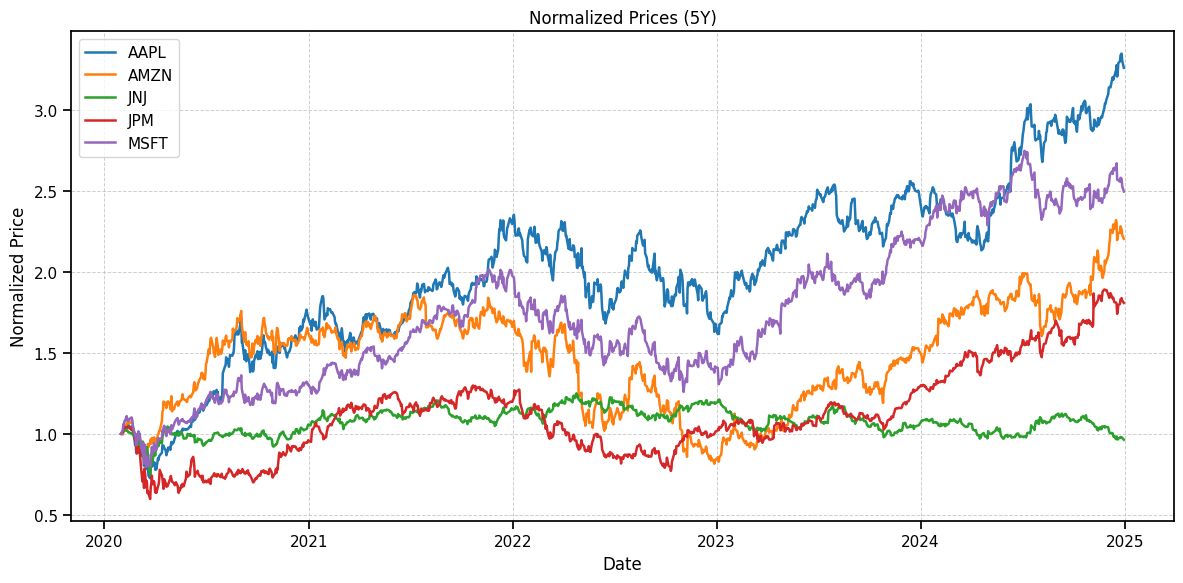

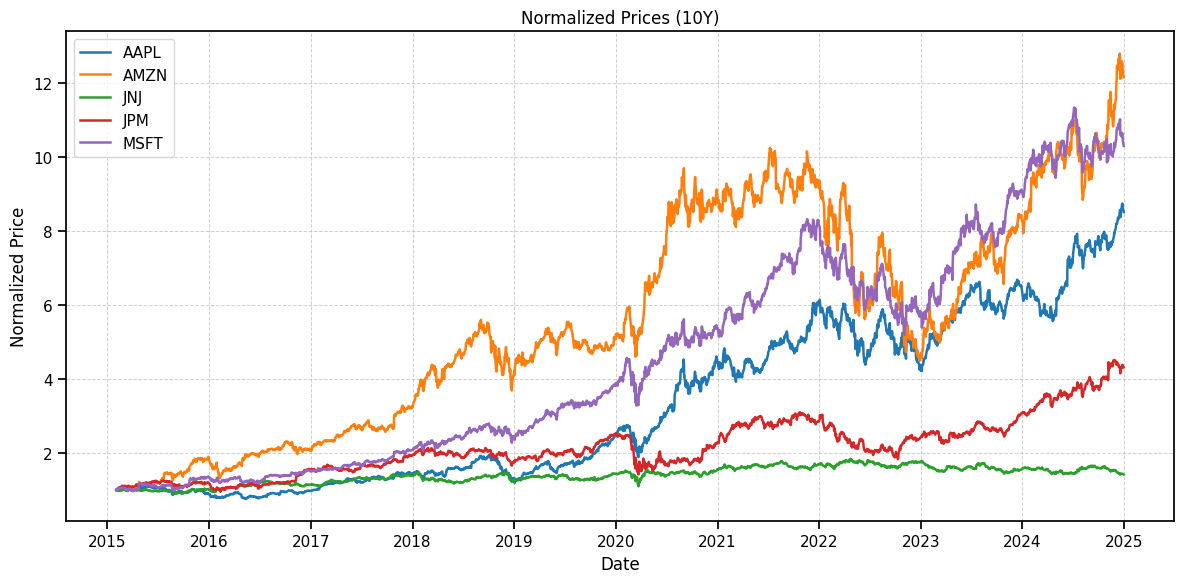

In [19]:
# ============================================================
# CELL 17 — Normalized price plots
# ============================================================

def plot_normalized_prices(panel_df: pd.DataFrame, title: str, save_name: str):
    wide_close = panel_df.pivot(index="date", columns="asset", values="Close").sort_index()
    norm = wide_close / wide_close.iloc[0]

    plt.figure(figsize=(12, 6))
    for col in norm.columns:
        plt.plot(norm.index, norm[col], label=col, linewidth=1.8)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Normalized Price")
    plt.legend(loc="best")
    plt.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.6)
    plt.tight_layout()

    save_figure(f"{OUTPUTS_DATA_ANALYSIS_DIR}/{save_name}")

plot_normalized_prices(panel_5y, "Normalized Prices (5Y)", "normalized_prices_5y.png")
plot_normalized_prices(panel_10y, "Normalized Prices (10Y)", "normalized_prices_10y.png")

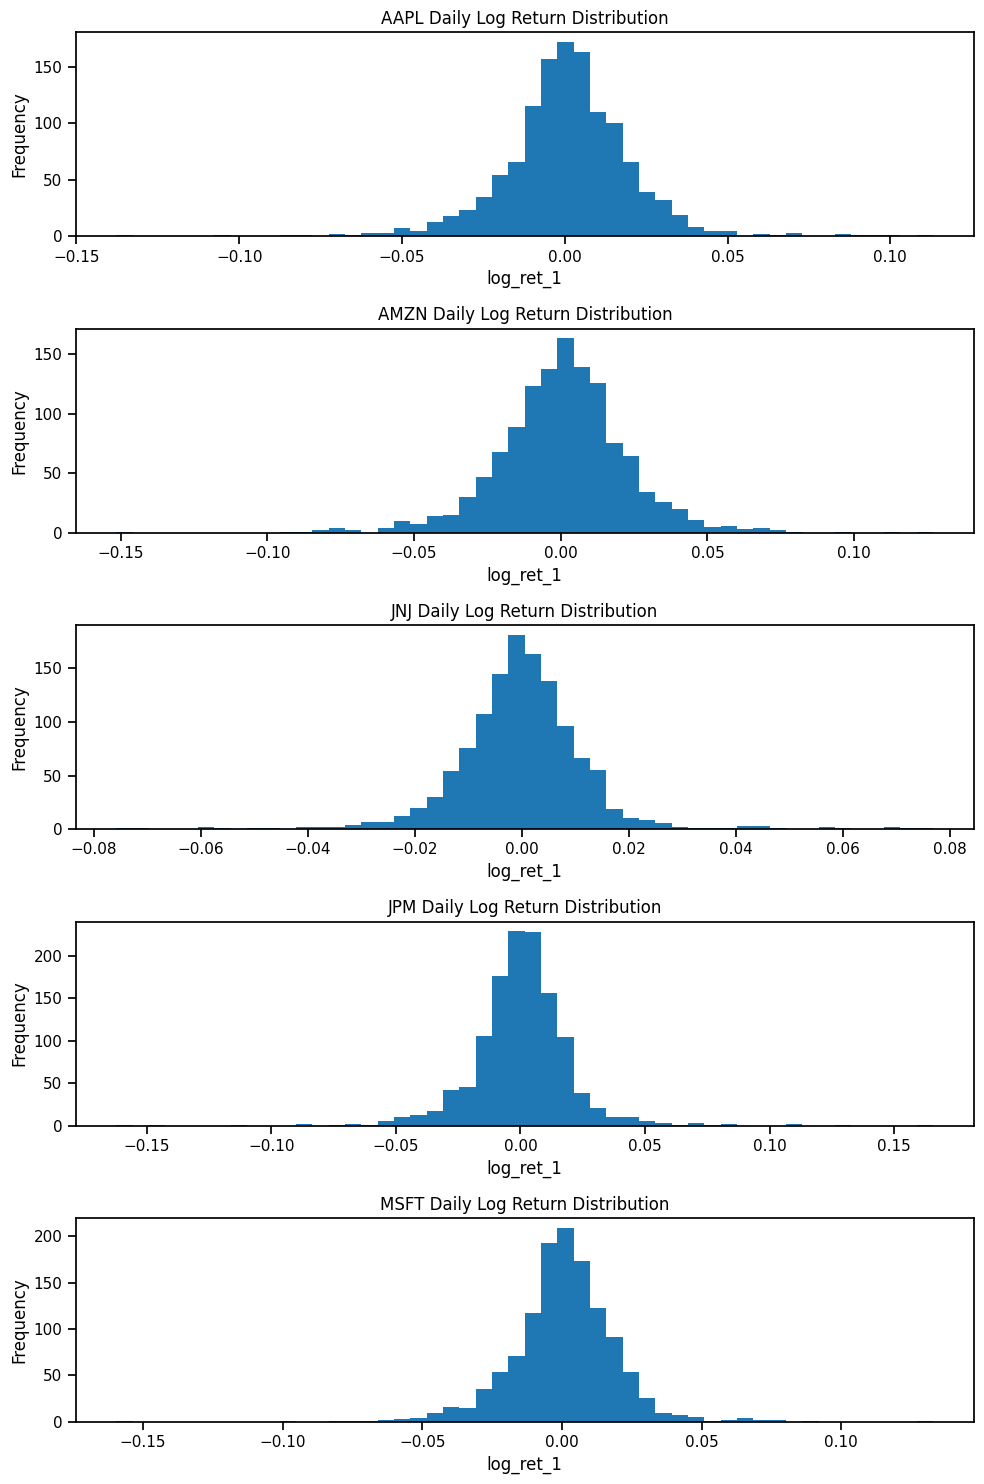

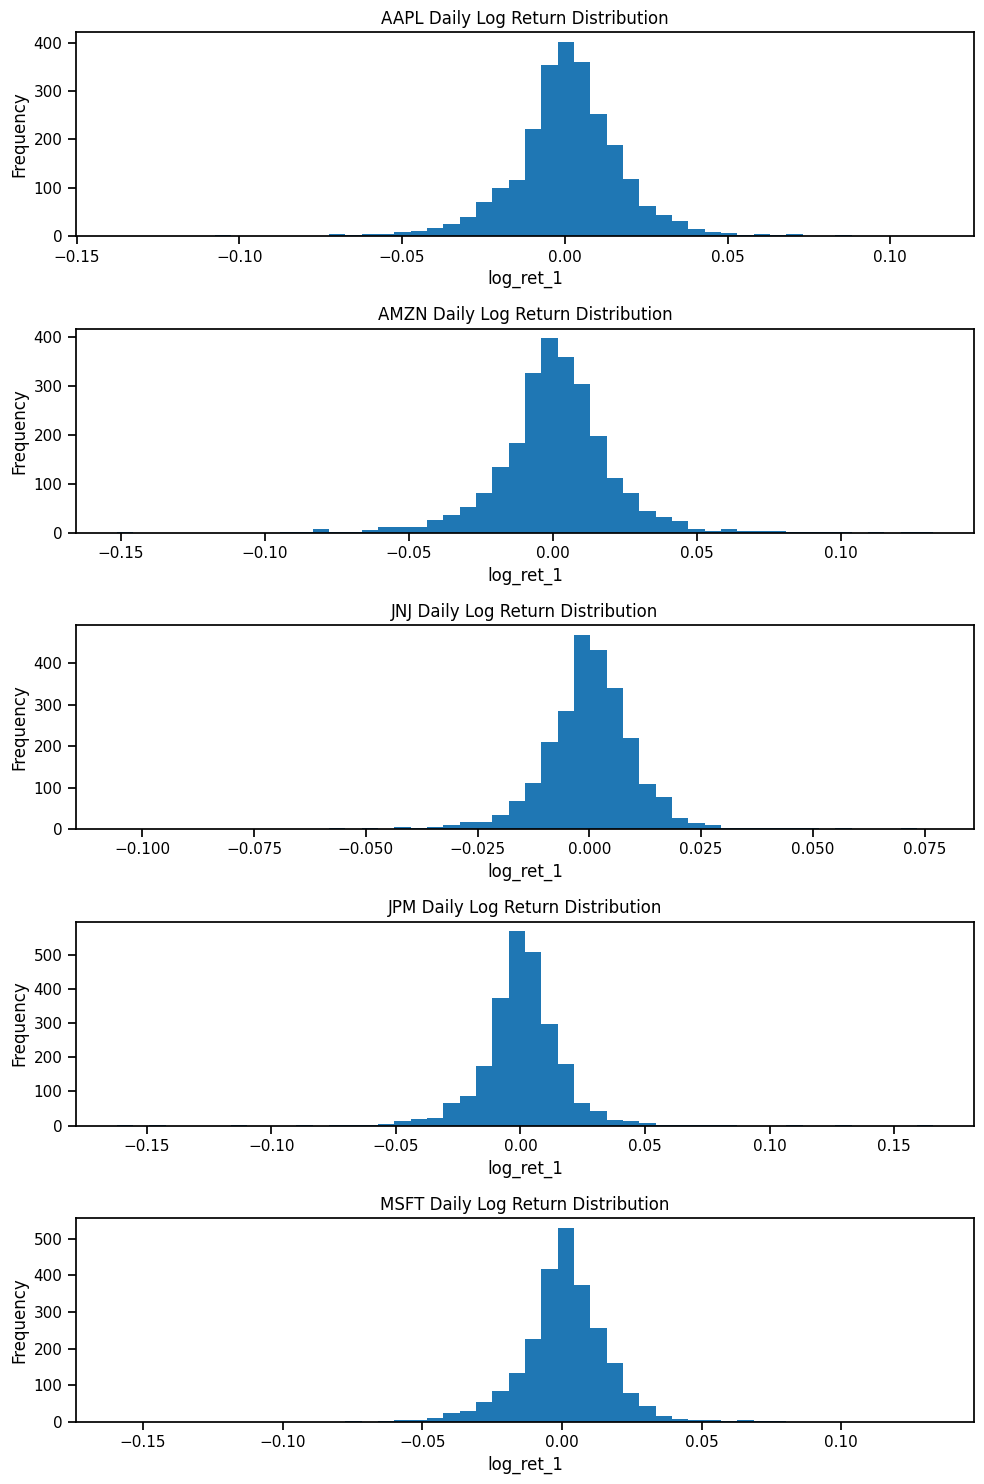

In [20]:
# ============================================================
# CELL 18 — Daily log return distributions (histogram)
# ============================================================

def plot_log_return_histograms(panel_df: pd.DataFrame, suffix: str):
    assets = sorted(panel_df["asset"].unique())
    fig, axes = plt.subplots(len(assets), 1, figsize=(10, 3 * len(assets)))

    if len(assets) == 1:
        axes = [axes]

    for ax, asset in zip(axes, assets):
        part = panel_df[panel_df["asset"] == asset]
        ax.hist(part["log_ret_1"].dropna(), bins=50)
        ax.set_title(f"{asset} Daily Log Return Distribution")
        ax.set_xlabel("log_ret_1")
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.savefig(f"{OUTPUTS_DATA_ANALYSIS_DIR}/log_return_histograms_{suffix}.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_log_return_histograms(panel_5y, "5y")
plot_log_return_histograms(panel_10y, "10y")

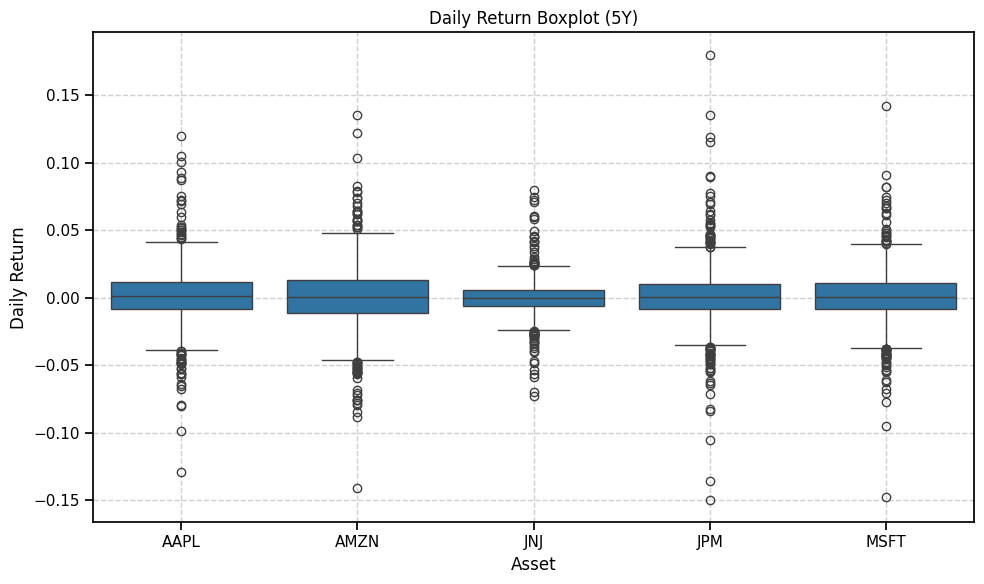

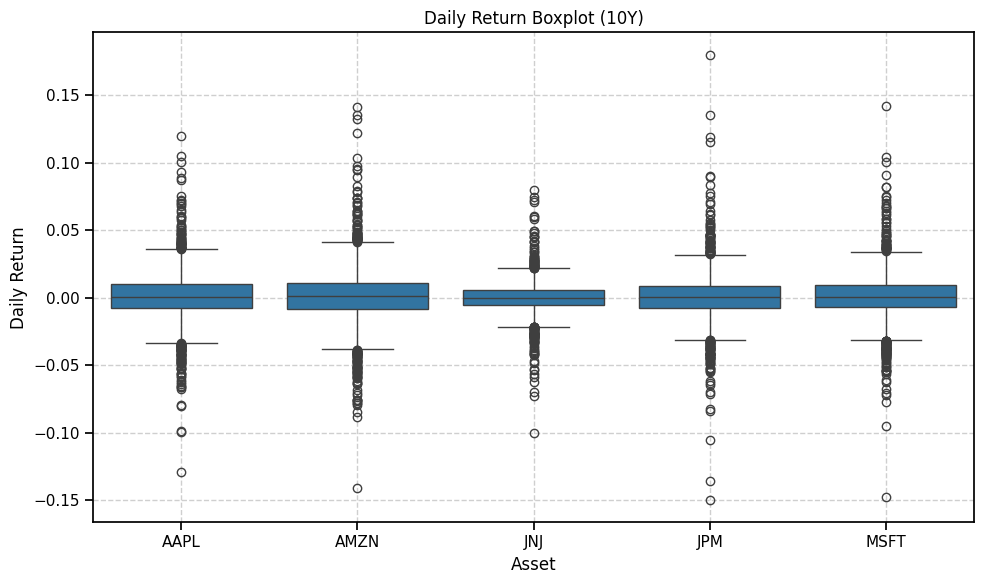

In [21]:
# ============================================================
# CELL 19 — Boxplot of daily returns
# ============================================================

def plot_return_boxplot(panel_df: pd.DataFrame, title: str, save_name: str):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=panel_df, x="asset", y="ret_1")
    plt.title(title)
    plt.xlabel("Asset")
    plt.ylabel("Daily Return")

    # thêm đường kẻ
    plt.grid(True, linestyle="--", alpha=0.6)

    save_figure(f"{OUTPUTS_DATA_ANALYSIS_DIR}/{save_name}")

plot_return_boxplot(panel_5y, "Daily Return Boxplot (5Y)", "boxplot_ret1_5y.png")
plot_return_boxplot(panel_10y, "Daily Return Boxplot (10Y)", "boxplot_ret1_10y.png")

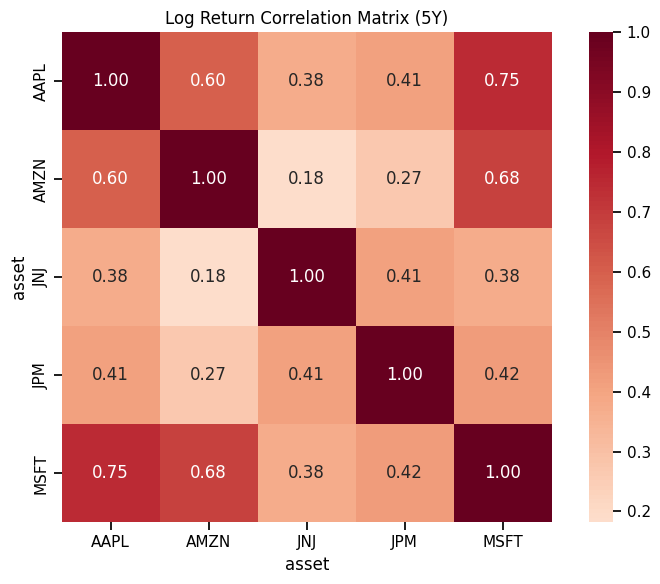

Saved correlation csv: /content/drive/MyDrive/thesis_rl_trading_final/outputs/data_analysis/corr_matrix_5y.csv


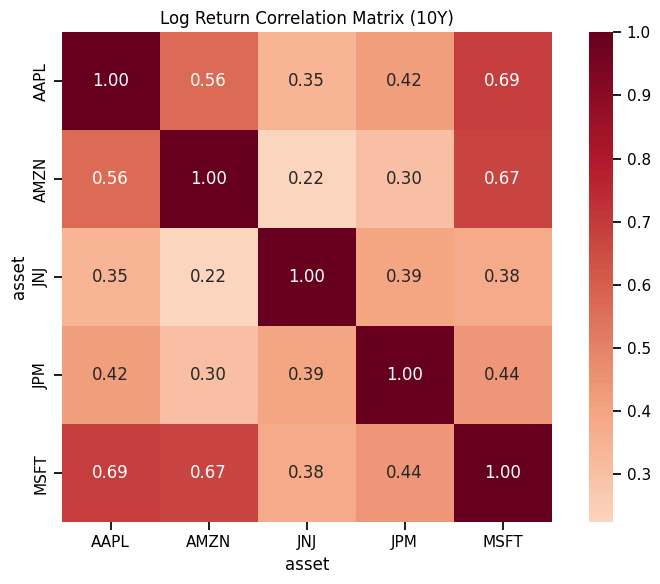

Saved correlation csv: /content/drive/MyDrive/thesis_rl_trading_final/outputs/data_analysis/corr_matrix_10y.csv


In [22]:
# ============================================================
# CELL 20 — Correlation matrix
# ============================================================

def plot_correlation_matrix(panel_df: pd.DataFrame, title: str, save_name: str):
    ret_wide = panel_df.pivot(index="date", columns="asset", values="log_ret_1").sort_index()
    corr = ret_wide.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", square=True, cmap="RdBu_r", center=0)
    plt.title(title)
    save_figure(f"{OUTPUTS_DATA_ANALYSIS_DIR}/{save_name}")

    corr.to_csv(f"{OUTPUTS_DATA_ANALYSIS_DIR}/{save_name.replace('.png', '.csv')}")
    print("Saved correlation csv:", f"{OUTPUTS_DATA_ANALYSIS_DIR}/{save_name.replace('.png', '.csv')}")

plot_correlation_matrix(panel_5y, "Log Return Correlation Matrix (5Y)", "corr_matrix_5y.png")
plot_correlation_matrix(panel_10y, "Log Return Correlation Matrix (10Y)", "corr_matrix_10y.png")

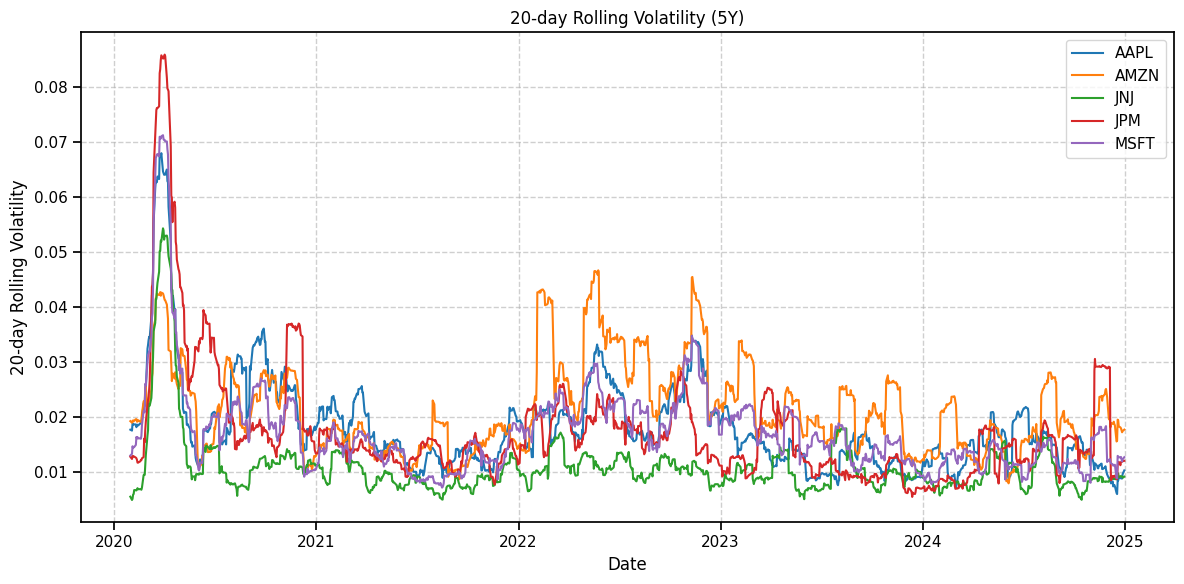

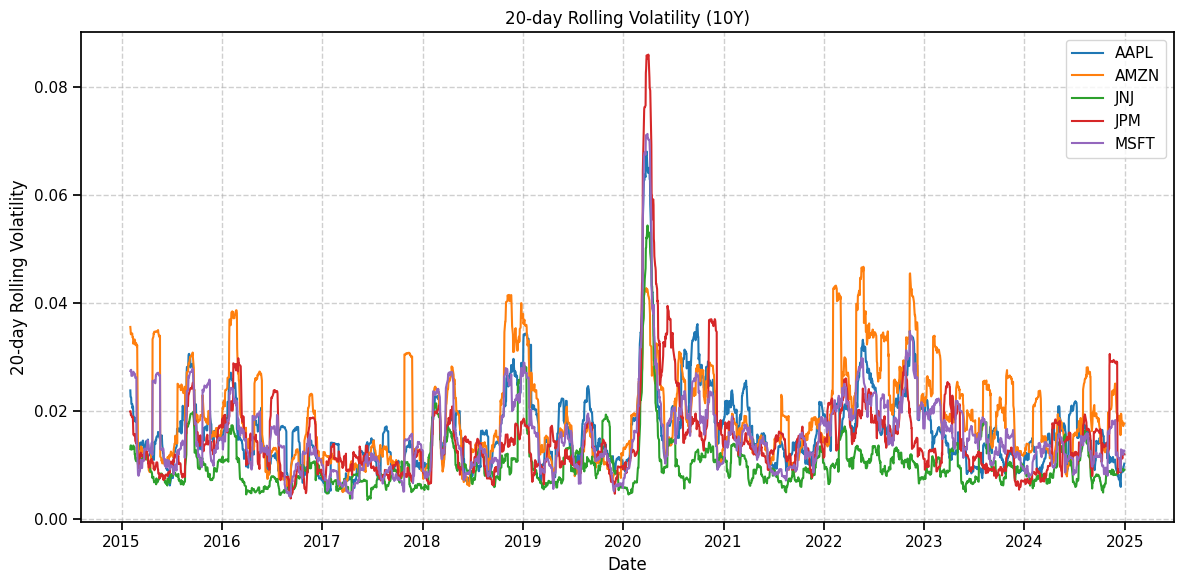

In [23]:
# ============================================================
# CELL 21 — Rolling volatility plots
# ============================================================

def plot_rolling_volatility(panel_df: pd.DataFrame, title: str, save_name: str):
    vol_wide = panel_df.pivot(index="date", columns="asset", values="vol_20").sort_index()

    plt.figure(figsize=(12, 6))
    for col in vol_wide.columns:
        plt.plot(vol_wide.index, vol_wide[col], label=col)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("20-day Rolling Volatility")
    plt.legend()

    # thêm đường kẻ
    plt.grid(True, linestyle="--", alpha=0.6)

    save_figure(f"{OUTPUTS_DATA_ANALYSIS_DIR}/{save_name}")

plot_rolling_volatility(panel_5y, "20-day Rolling Volatility (5Y)", "rolling_volatility_5y.png")
plot_rolling_volatility(panel_10y, "20-day Rolling Volatility (10Y)", "rolling_volatility_10y.png")

In [24]:
# ============================================================
# CELL 22 — Save split summary
# ============================================================

def make_split_summary(panel_df: pd.DataFrame, save_path: str):
    summary = (
        panel_df.groupby("split")
        .agg(
            start_date=("date", "min"),
            end_date=("date", "max"),
            n_rows=("date", "size"),
            n_unique_dates=("date", "nunique"),
        )
        .reset_index()
    )
    summary.to_csv(save_path, index=False)
    print("Saved:", save_path)
    return summary

split_summary_5y = make_split_summary(
    panel_5y,
    f"{OUTPUTS_DATA_ANALYSIS_DIR}/split_summary_5y.csv"
)

split_summary_10y = make_split_summary(
    panel_10y,
    f"{OUTPUTS_DATA_ANALYSIS_DIR}/split_summary_10y.csv"
)

display(split_summary_5y)
display(split_summary_10y)

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/data_analysis/split_summary_5y.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/data_analysis/split_summary_10y.csv


,split,start_date,end_date,n_rows,n_unique_dates
0,test,2024-01-02,2024-12-30,1255,251
1,train,2020-01-31,2022-12-30,3680,736
2,val,2023-01-03,2023-12-29,1250,250


,split,start_date,end_date,n_rows,n_unique_dates
0,test,2023-01-03,2024-12-30,2505,501
1,train,2015-02-02,2020-12-31,7455,1491
2,val,2021-01-04,2022-12-30,2515,503


In [25]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=split_summary_10y)

https://docs.google.com/spreadsheets/d/1LZ8AiVH3YsOYYyXmPzF4YtY6LSX2sz7nLGcElt-PW0k/edit#gid=0


In [26]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=split_summary_5y)

https://docs.google.com/spreadsheets/d/1A8CsPeTuwcpUR92O8BoECjMoslGBrMnXsmXwrhPKC2Y/edit#gid=0


In [27]:
# ============================================================
# CELL 23 — Final sanity checks
# ============================================================

assert set(panel_5y["asset"].unique()) == set(ASSETS)
assert set(panel_10y["asset"].unique()) == set(ASSETS)

assert bundle_5y["X"].shape[1] == LOOKBACK
assert bundle_10y["X"].shape[1] == LOOKBACK

assert bundle_5y["X"].shape[2] == len(ASSETS)
assert bundle_10y["X"].shape[2] == len(ASSETS)

assert bundle_5y["X"].shape[3] == len(FEATURE_COLS)
assert bundle_10y["X"].shape[3] == len(FEATURE_COLS)

assert set(np.unique(bundle_5y["splits"])) <= {"train", "val", "test"}
assert set(np.unique(bundle_10y["splits"])) <= {"train", "val", "test"}

print("All sanity checks passed.")
print("5Y tensor shape:", bundle_5y["X"].shape, bundle_5y["y"].shape)
print("10Y tensor shape:", bundle_10y["X"].shape, bundle_10y["y"].shape)

All sanity checks passed.
5Y tensor shape: (1218, 20, 5, 13) (1218, 5)
10Y tensor shape: (2476, 20, 5, 13) (2476, 5)


In [28]:
# ============================================================
# CELL 24 — What this notebook outputs
# ============================================================

produced_files = [
    f"{DATA_PROCESSED_DIR}/panel_5y.csv",
    f"{DATA_PROCESSED_DIR}/panel_10y.csv",
    f"{DATA_PROCESSED_DIR}/tensor_bundle_5y.npz",
    f"{DATA_PROCESSED_DIR}/tensor_bundle_10y.npz",
    f"{CONFIGS_DIR}/master_config.json",
    f"{CONFIGS_DIR}/feature_columns.json",
    f"{OUTPUTS_DATA_ANALYSIS_DIR}/descriptive_stats_adf_5y.csv",
    f"{OUTPUTS_DATA_ANALYSIS_DIR}/descriptive_stats_adf_10y.csv",
    f"{OUTPUTS_DATA_ANALYSIS_DIR}/split_summary_5y.csv",
    f"{OUTPUTS_DATA_ANALYSIS_DIR}/split_summary_10y.csv",
]

for fp in produced_files:
    print(fp, "->", os.path.exists(fp))

/content/drive/MyDrive/thesis_rl_trading_final/data_processed/panel_5y.csv -> True
/content/drive/MyDrive/thesis_rl_trading_final/data_processed/panel_10y.csv -> True
/content/drive/MyDrive/thesis_rl_trading_final/data_processed/tensor_bundle_5y.npz -> True
/content/drive/MyDrive/thesis_rl_trading_final/data_processed/tensor_bundle_10y.npz -> True
/content/drive/MyDrive/thesis_rl_trading_final/configs/master_config.json -> True
/content/drive/MyDrive/thesis_rl_trading_final/configs/feature_columns.json -> True
/content/drive/MyDrive/thesis_rl_trading_final/outputs/data_analysis/descriptive_stats_adf_5y.csv -> True
/content/drive/MyDrive/thesis_rl_trading_final/outputs/data_analysis/descriptive_stats_adf_10y.csv -> True
/content/drive/MyDrive/thesis_rl_trading_final/outputs/data_analysis/split_summary_5y.csv -> True
/content/drive/MyDrive/thesis_rl_trading_final/outputs/data_analysis/split_summary_10y.csv -> True
